In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
def v_pm_relation(alpha_plus, v_minus, type="detonation"):
    """
    Calculate the velocity relation between phases in a phase transition.
    
    This function computes the velocity v_plus (velocity in the positive region)
    based on the velocity v_minus (velocity in the negative region) and the 
    energy density ratio alpha_plus, for either detonation or deflagration modes.
    
    Parameters:
    alpha_plus (float): Energy density ratio across the phase boundary (dimensionless).
    v_minus (float): Velocity in the minus (incoming) region, normalized by speed of light.
    type (str, optional): Type of phase transition: "detonation" or "deflagration". Default is "detonation".
    
    Returns:
    v_plus (float): Velocity in the plus (outgoing) region, normalized by speed of light.
    """
    # Normalization factor accounting for energy density difference
    factor = 1 / (1 + alpha_plus)
    
    # Intermediate argument
    arg = v_minus / 2 + 1 / (6 * v_minus)
    
    if type == "detonation":
        # Detonation: supersonic combustion wave (positive branch)
        v_plus = factor * (arg + np.sqrt(arg**2 + alpha_plus**2 + (2/3) * alpha_plus - 1/3))
    elif type == "deflagration":
        # Deflagration: subsonic combustion wave (negative branch)
        v_plus = factor * (arg - np.sqrt(arg**2 + alpha_plus**2 + (2/3) * alpha_plus - 1/3))
    
    return v_plus

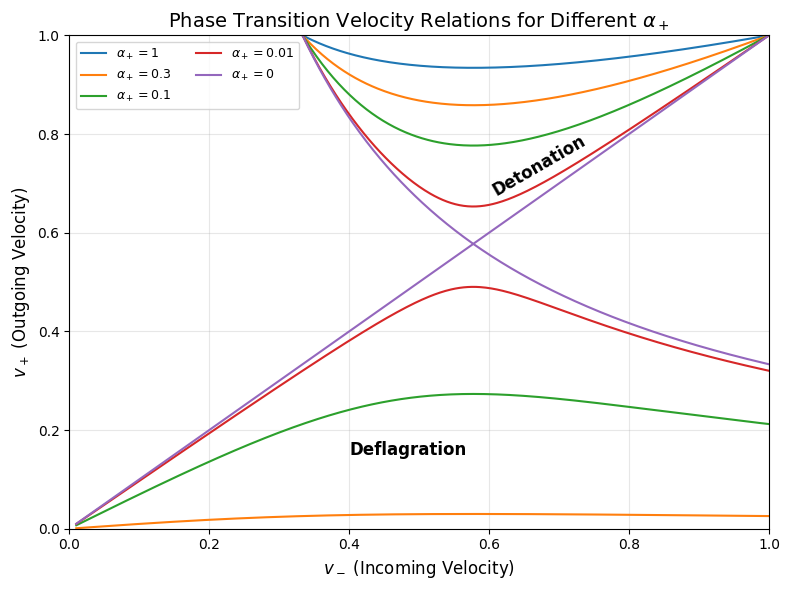

In [3]:
# Velocity Relations for Phase Transitions
# Plot v_+ vs v_- for various energy density ratios (α_+)
# showing both detonation (supersonic) and deflagration (subsonic) branches

# Define parameter range
alpha_plus_list = [1, 0.3, 0.1, 0.01, 0]  # Energy density ratios to explore
v_minus_values = np.linspace(0.01, 1.0, 500)  # Incoming velocity range

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Plot curves for each α_+ value
for alpha_plus in alpha_plus_list:
    # Calculate detonation branch (supersonic)
    v_plus_det = [v_pm_relation(alpha_plus, v_minus, type="detonation") 
                  for v_minus in v_minus_values]
    line, = ax.plot(v_minus_values, v_plus_det, 
                    label=rf"$\alpha_+={alpha_plus}$")
    
    # Calculate deflagration branch (subsonic) using same color
    v_plus_def = [v_pm_relation(alpha_plus, v_minus, type="deflagration") 
                  for v_minus in v_minus_values]
    ax.plot(v_minus_values, v_plus_def, color=line.get_color())

# Add region labels
ax.text(0.6, 0.675, "Detonation", fontsize=12, rotation=30, 
        color="black", weight="bold")
ax.text(0.4, 0.15, "Deflagration", fontsize=12, 
        color="black", weight="bold")

# Configure plot aesthetics
ax.set_xlabel(r"$v_-$ (Incoming Velocity)", fontsize=12)
ax.set_ylabel(r"$v_+$ (Outgoing Velocity)", fontsize=12)
ax.set_title(r"Phase Transition Velocity Relations for Different $\alpha_+$", 
             fontsize=14)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(fontsize=9, ncol=2, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

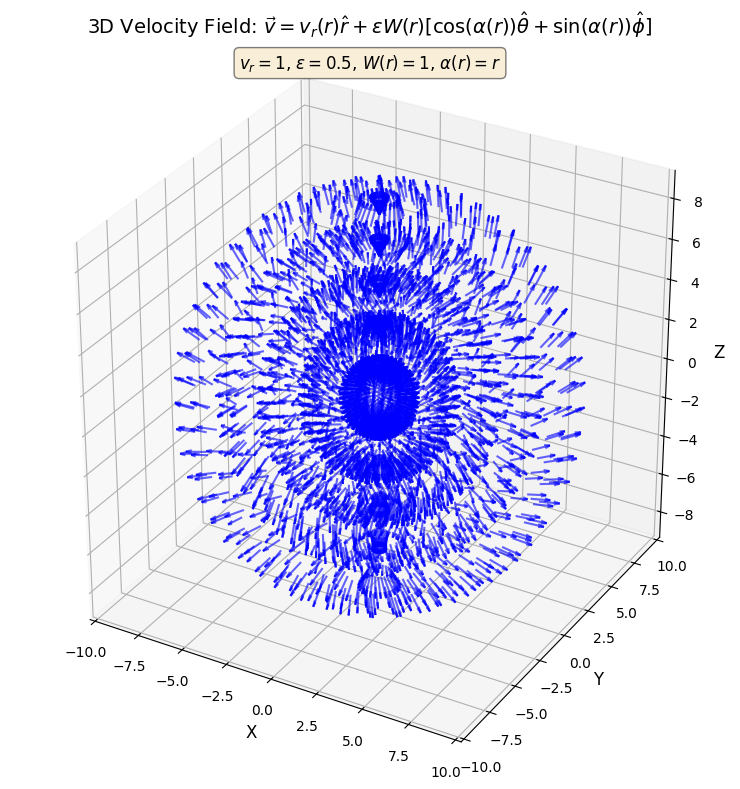

In [4]:
# 3D Velocity Field Visualization in Spherical Coordinates
# Visualizes a velocity field of the form: v = v_r(r)*r_hat + ε*W(r)*[cos(α(r))*θ_hat + sin(α(r))*φ_hat]
# where the radial component dominates and angular components provide perturbations

# Configuration parameters
epsilon = 0.5
W = lambda r: 1
alpha = lambda r: r
v_r = lambda r: 1

# Spatial grid setup
r_values = np.linspace(1, 10, 10)
theta_values = np.linspace(0, np.pi, 50)
phi_values = np.linspace(0, 2*np.pi, 50)

# Create 3D mesh grid in spherical coordinates (r, θ, φ)
R, THETA, PHI = np.meshgrid(r_values, theta_values, phi_values, indexing="ij")

# Coordinate transformation
X = R * np.sin(THETA) * np.cos(PHI)
Y = R * np.sin(THETA) * np.sin(PHI)
Z = R * np.cos(THETA)

# Velocity field in spherical components
V_r = v_r(R)       
V_theta = epsilon * W(R) * np.cos(alpha(R))
V_phi = epsilon * W(R) * np.sin(alpha(R))

# Velocity transformation
V_x = (V_r * np.sin(THETA) * np.cos(PHI) + 
       V_theta * np.cos(THETA) * np.cos(PHI) - 
       V_phi * np.sin(PHI))

V_y = (V_r * np.sin(THETA) * np.sin(PHI) + 
       V_theta * np.cos(THETA) * np.sin(PHI) + 
       V_phi * np.cos(PHI))

V_z = V_r * np.cos(THETA) - V_theta * np.sin(THETA)

# Plotting the 3D velocity field
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

# Plot velocity vectors (subsample for visual clarity)
step = 2  # Plot every 2nd point to avoid overcrowding
ax.quiver(X[::step, ::step, ::step], 
          Y[::step, ::step, ::step], 
          Z[::step, ::step, ::step],
          V_x[::step, ::step, ::step], 
          V_y[::step, ::step, ::step], 
          V_z[::step, ::step, ::step],
          length=1, normalize=True, color="blue", alpha=0.6)

# Plot annotations
ax.set_xlabel("X", fontsize=12)
ax.set_ylabel("Y", fontsize=12)
ax.set_zlabel("Z", fontsize=12)
ax.set_title(r"3D Velocity Field: $\vec{v} = v_r(r)\hat{r} + \epsilon W(r)[\cos(\alpha(r))\hat{\theta} + \sin(\alpha(r))\hat{\phi}]$", 
             fontsize=14, pad=10)

# Dynamically generate parameter text based on actual function definitions
# Extract function expressions for display
v_r_expr = "1" if callable(v_r) and v_r(1) == 1 else "v_r(r)"
W_expr = "1" if callable(W) and W(1) == 1 else "W(r)"
alpha_expr = "r" if callable(alpha) and alpha(1) == 1 else "\\alpha(r)"

param_text = f"$v_r = {v_r_expr}$, $\\epsilon = {epsilon}$, $W(r) = {W_expr}$, $\\alpha(r) = {alpha_expr}$"
ax.text2D(0.5, 0.97, param_text, transform=ax.transAxes, 
          fontsize=12, ha="center", 
          bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

# Adjust aspect ratio and layout
ax.set_box_aspect([1, 1, 1])
plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05)
plt.show()